x
[ScalarEvent(wall_time=1767963467.4004638, step=0, value=0.10260000079870224), ScalarEvent(wall_time=1767963474.6714585, step=1, value=0.19259999692440033), ScalarEvent(wall_time=1767963481.9590065, step=2, value=0.20469999313354492), ScalarEvent(wall_time=1767963489.2546341, step=3, value=0.21170000731945038), ScalarEvent(wall_time=1767963498.1499743, step=4, value=0.20489999651908875), ScalarEvent(wall_time=1767963507.0404432, step=5, value=0.30550000071525574), ScalarEvent(wall_time=1767963515.916867, step=6, value=0.25929999351501465), ScalarEvent(wall_time=1767963524.0937705, step=7, value=0.3248000144958496), ScalarEvent(wall_time=1767963532.2372808, step=8, value=0.3273000121116638), ScalarEvent(wall_time=1767963540.455009, step=9, value=0.34779998660087585), ScalarEvent(wall_time=1767963549.3821437, step=10, value=0.17350000143051147), ScalarEvent(wall_time=1767963558.3163066, step=11, value=0.18170000612735748), ScalarEvent(wall_time=1767963567.1973665, step=12, value=0.1066

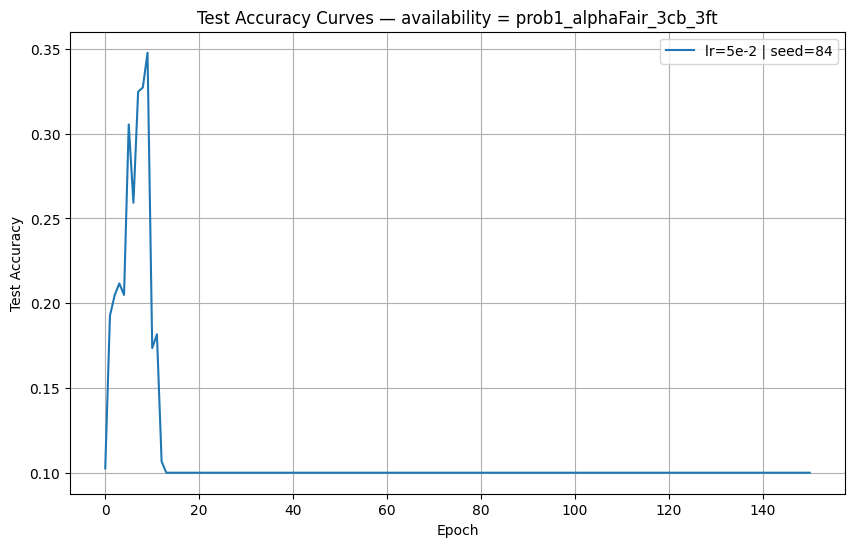

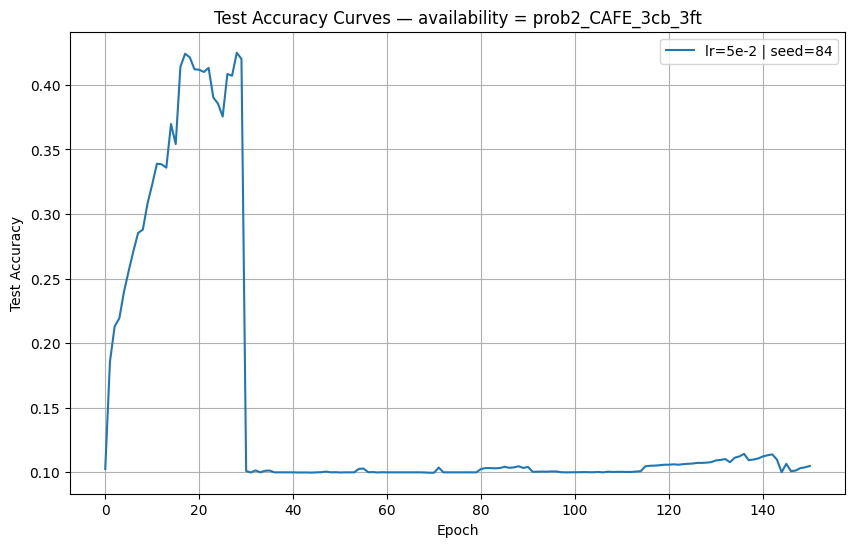

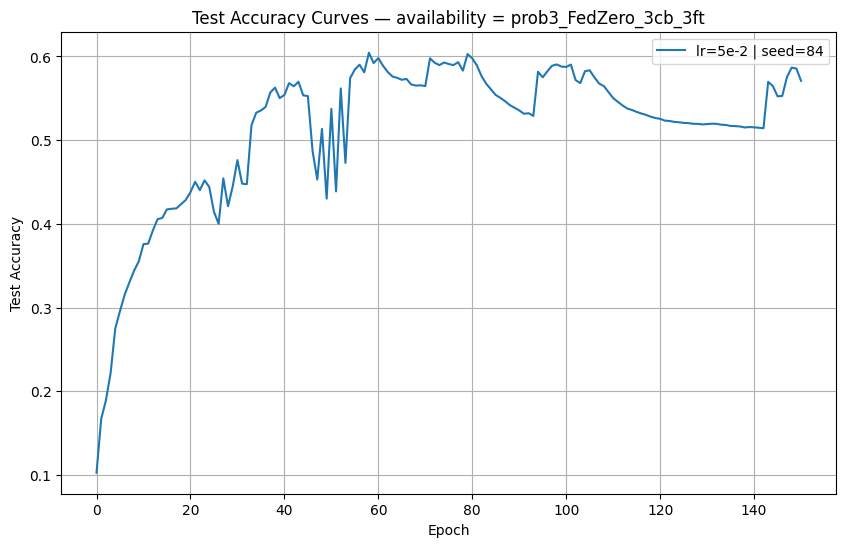

In [2]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from matplotlib import pyplot as plt
# from plots_utils.loading import parse_tf_events_file
import numpy as np
import pandas as pd

from pathlib import Path
import os

def parse_tf_events_file(events_path, tag, time_horizon=None):
    """
    Returns the data in the file located in the folder events_paths,
    and corresponding to the tag.
    The tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'.
    """
    ea = EventAccumulator(events_path).Reload()
    print(ea)
    print(list(ea.Scalars(tag)))
    tag_values, steps = [], []
    for event in ea.Scalars(tag):
        if time_horizon is None or event.step <= time_horizon:
            tag_values.append(event.value)
            steps.append(event.step)
    return steps, tag_values

def get_exp_stats(config):
    results = list()
    for lr in config.lr_list:
        # time_horizon = time_horizons[p]  
        for algorithm in config.algorithms:
            # b_loop = config.b_values if algorithm == 'mixture' else [None] # in case we vary beta
            # for b in b_loop:
            for event in config.events:
                for seed in config.seeds:
                    for a in config.alphas:
                        for n_c in config.n_clients_list:
                            for av in config.availabilities:
                                for part in config.participations:
                                    for biased in config.biased_list:

                                        event_dir = config.get_event_dir(algorithm, lr, seed, 
                                                                            event, a, n_c, av, 
                                                                            config.n_rounds, part, biased, config.train_test)
                                        # print(event_dir)
                                        # print(event_dir.split('/'))
                                        # print(os.path.exists(event_dir))


                                        if os.path.exists(event_dir):
                                            # print('helloooo')
                                            print('x')
                                            # _, values = parse_tf_events_file(event_dir, tag="Test/Metric", time_horizon=time_horizon)
                                            _, test_accuracy_values = parse_tf_events_file(event_dir, tag="Test/Metric")
                                            # _, test_loss_values = parse_tf_events_file(event_dir, tag="Test/Loss")
                                            # _, train_accuracy_values = parse_tf_events_file(event_dir, tag="Train/Metric")
                                            # _, train_loss_values = parse_tf_events_file(event_dir, tag="Train/Loss")
                                            ### tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'
                                            max_accuracy = np.array(test_accuracy_values).max() * 100
                                            results.append({
                                                "algorithm": algorithm, 
                                                "availability": av,
                                                "alpha": a, 
                                                "participation": part,
                                                "max_test_accuracy": float(max_accuracy),
                                                "final_test_accuracy":test_accuracy_values[-1]*100,
                                                "test_accuracy": np.array(test_accuracy_values),
                                                "seed": seed,
                                                "lr": lr, "event": event, "n_clients": n_c,
                                                "biased": biased
                                            })

                                            # "b": float(b) if b else np.nan # in case we vary beta
    return pd.DataFrame(results)

main_folder = 'baselines_accuracy_check'
# ['1e-1', '1e-2', '1e-3', '1e-4', "5e-2"]
availabilities="prob1_alphaFair_7cb_3ft prob2_CAFE_7cb_3ft prob3_FedZero_7cb_3ft".split()
# availabilities="prob1_alphaFair_1cb_3ft prob1_alphaFair_2cb_3ft prob1_alphaFair_3cb_3ft prob1_alphaFair_4cb_3ft prob1_alphaFair_5cb_3ft prob1_alphaFair_6cb_3ft prob1_alphaFair_7cb_3ft".split()
# availabilities="prob2_CAFE_1cb_3ft prob2_CAFE_2cb_3ft prob2_CAFE_3cb_3ft prob2_CAFE_4cb_3ft prob2_CAFE_5cb_3ft prob2_CAFE_6cb_3ft prob2_CAFE_7cb_3ft".split()
# availabilities="prob3_FedZero_1cb_3ft prob3_FedZero_2cb_3ft prob3_FedZero_3cb_3ft prob3_FedZero_4cb_3ft prob3_FedZero_5cb_3ft prob3_FedZero_6cb_3ft prob3_FedZero_7cb_3ft".split()
exp_folder="mnist_baselines_with_ft"

# availabilities="prob1_alphaFair_3cb_3ft prob2_CAFE_3cb_3ft prob3_FedZero_3cb_3ft".split()
availabilities="prob1_alphaFair_3cb_3ft prob2_CAFE_3cb_3ft prob3_FedZero_3cb_3ft".split()
exp_folder="cifar_baselines_with_ft_group_notclip"

# config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment=exp_folder, seeds=["42", "78", "84"],
#                           algorithms=["fedavg"], events=["global"],
#                           lr_list=['5e-2', '1e-2'], alphas=["0.5"], n_clients_list=["7"],
#                           availabilities=availabilities,
#                           n_rounds="150", participations=["known"], biased_list=["2"], train_test="train")
config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment=exp_folder, seeds=["84"],
                          algorithms=["fedavg"], events=["global"],
                          lr_list=['5e-2'], alphas=["0.5"], n_clients_list=["7"],
                          availabilities=availabilities,
                          n_rounds="150", participations=["known"], biased_list=["2"], train_test="train")
results_df = get_exp_stats(config)

results_df

# display(results_df)

import ast

# Convert 'test_accuracy' column to lists if needed
results_df['test_accuracy'] = results_df['test_accuracy'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Loop over availability groups
for availability_value, group in results_df.groupby("availability"):
    
    plt.figure(figsize=(10, 6))
    
    for _, row in group.iterrows():
        label = f"lr={row['lr']} | seed={row['seed']}"
        plt.plot(row['test_accuracy'], label=label)
    
    plt.title(f"Test Accuracy Curves — availability = {availability_value}")
    plt.xlabel("Epoch")
    plt.ylabel("Test Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()